In [39]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile

# for contours
import scipy.optimize as so 

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

# Lab 7  Contour Plots and Spiral Arms

In this lab you will: 

A) Use contour plots to identify substructure within the stellar disk of M31.

B) Rotate the disk so that we are seeing it edge on

C) Create plots to examine the kinematics of the disk

D) Create plots to study spiral arms

Use the CenterOfMass code to compute the positions and velocities of all particles in M31's disk relative to its center of mass position and motion.

In [257]:
# Create a COM of object for M33 Halo (particle type=1) Using Code from Homework 4
COMD = CenterOfMass("M33_000.txt",1)

In [258]:
# Compute COM of M33 using halo particles
COMP = COMD.COM_P(0.1)
COMV = COMD.COM_V(COMP[0],COMP[1],COMP[2])

In [259]:
# Determine positions of halo particles relative to COM 
xD = COMD.x - COMP[0].value 
yD = COMD.y - COMP[1].value 
zD = COMD.z - COMP[2].value 

# total magnitude
rtot = np.sqrt(xD**2 + yD**2 + zD**2)

# Determine velocities of halo particles relative to COM motion
vxD = COMD.vx - COMV[0].value 
vyD = COMD.vy - COMV[1].value 
vzD = COMD.vz - COMV[2].value 

# total velocity 
vtot = np.sqrt(vxD**2 + vyD**2 + vzD**2)

# Arrays for r and v 
r = np.array([xD,yD,zD]).T # transposed 
v = np.array([vxD,vyD,vzD]).T

# Create 2D density histogram 

Create plot of M33's halo density, using 2D Histograms 

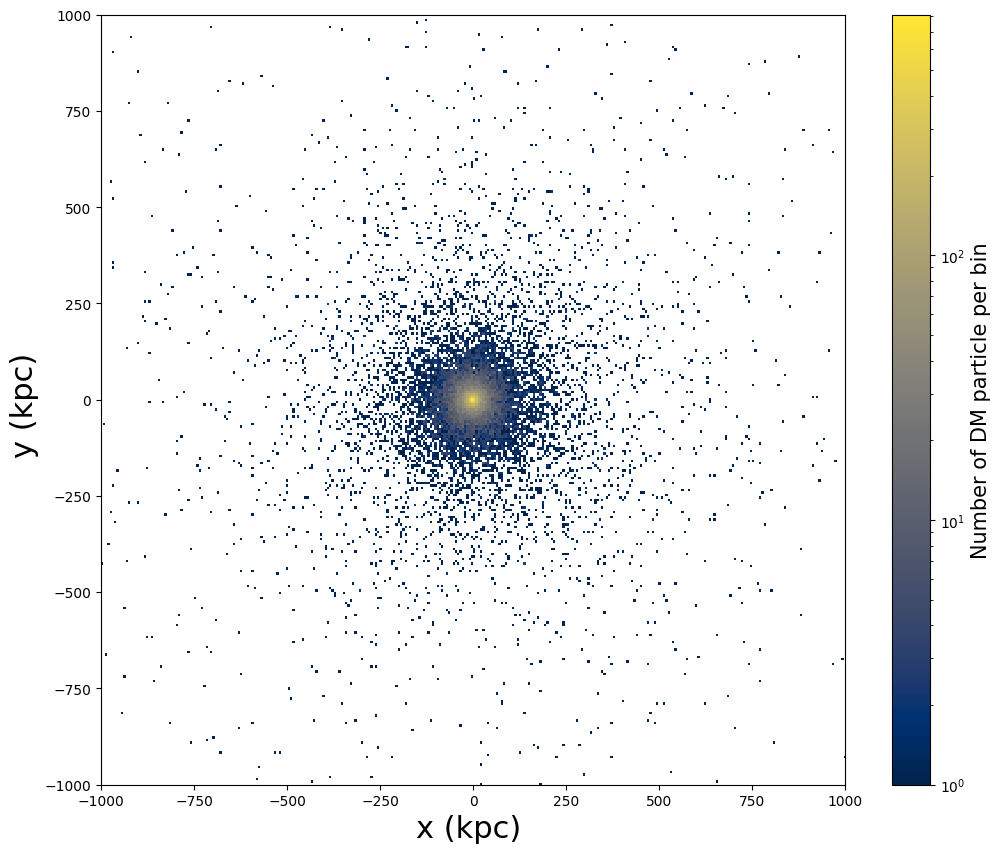

In [291]:
# 1) Make plots 

# M33 Disk Density 
fig, ax= plt.subplots(figsize=(12, 10))

# ADD HERE
# plot the particle density for M33 using a 2D historgram
# plt.hist2D(pos1,pos2, bins=, norm=LogNorm(), cmap='' )
# cmap options: 
# https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html  
#   e.g. 'magma', 'viridis'
# can modify bin number to make the plot smoother
h = plt.hist2d(xD,yD, bins=1500, norm=LogNorm(), cmap='cividis')

cbar = plt.colorbar()
cbar.set_label("Number of DM particle per bin", fontsize=15)

# Add axis labels
plt.xlabel('x (kpc) ', fontsize=22)
plt.ylabel('y (kpc) ', fontsize=22)

#set axis limits
l = 1e3 # length of box to show in kpc
plt.ylim(-l,l)
plt.xlim(-l,l)

#adjust tick label font size
label_size = 10
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size



# Save to a file
#plt.savefig('Lab7_M31DMHalo.png', bbox_inches='tight')

In [304]:
def PlotEllipses(img_data, sma=10):
    """
    """
    fits_data = np.log10(img_data, where=(img_data != 0) )
    
    x0 = np.where(img_data == np.max(img_data))[1][0]
    y0 = np.where(img_data == np.max(img_data))[0][0]

    
    ny, nx = fits_data.shape
    geometry = EllipseGeometry(x0=x0, y0=y0, sma=sma, eps=0.3, pa=0.0, )
    
    ellipse = Ellipse(fits_data, geometry)
    isolist = ellipse.fit_image(maxsma=50)
    table = isolist.to_table()

    fig, ax = plt.subplots(figsize=(12, 10))
    sm = ax.imshow(img_data, norm=LogNorm(),  cmap='cividis', interpolation='none')
    w = nx * 0.05
    ax.set_xlim(x0 - w, x0 + w)
    ax.set_ylim(y0 - w, y0 + w)
    
    isos = []
    smas = np.arange(0, max(table['sma']), 1)
    for sma in smas:
        iso = isolist.get_closest(sma)
        isos.append(iso)
        x, y, = iso.sampled_coordinates()
        plt.plot(x, y, color='lime', linewidth=0.3, linestyle='-')

    cbar = plt.colorbar(sm)
    cbar.set_label("Number of DM particle per bin", fontsize=15)

Text(0, 0.5, 'y (pixels) ')

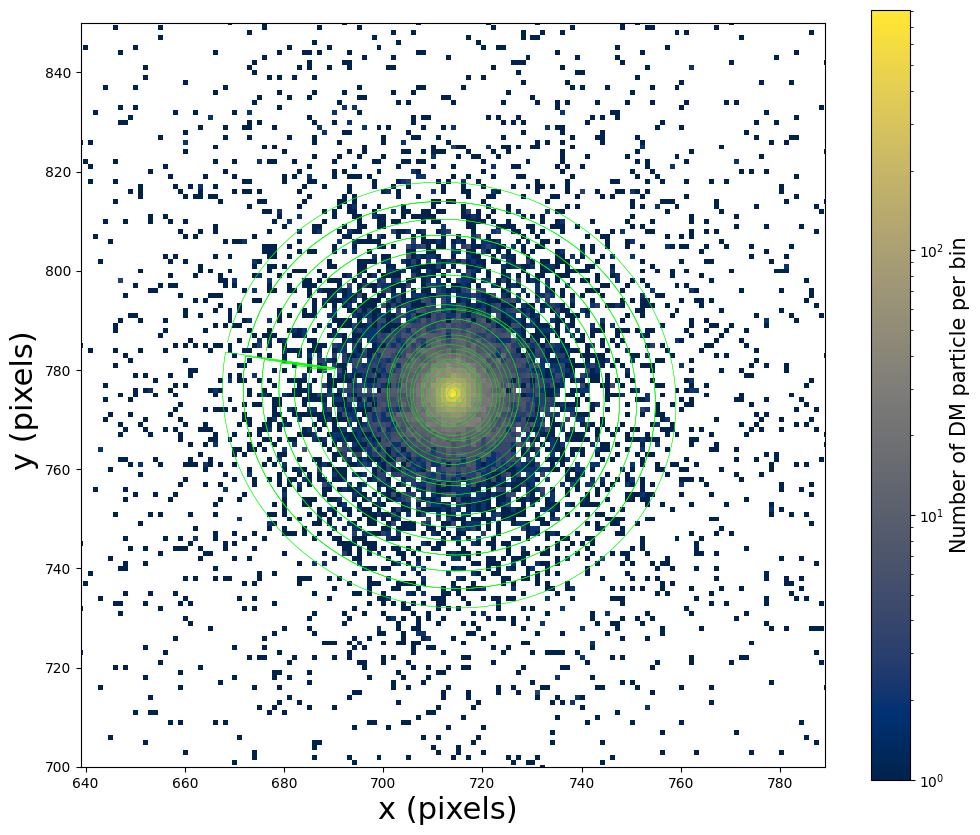

In [305]:
PlotEllipses(h[0], sma=10)

# Add axis labels
plt.xlabel('x (pixels) ', fontsize=22)
plt.ylabel('y (pixels) ', fontsize=22)